1- Importation des données

In [868]:
# Importation des packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement du dataset
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [869]:
# Infos générales
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


(32581, 12)

2- Identifier la variable cible

In [870]:
print("""
loan_status est la variable centrale du projet. C’est elle qui permet de mesurer : le taux de défaut global, le risque par 
segment et les profils les plus risqués.""")


loan_status est la variable centrale du projet. C’est elle qui permet de mesurer : le taux de défaut global, le risque par 
segment et les profils les plus risqués.


In [871]:
# Identifier la variable cible

df["loan_status"].value_counts()
df["loan_status"].mean()*100

print(f"Taux de défaut global : {df["loan_status"].mean()*100:.2f}%")

# Environ 21,82% clients du portefeuille sont en défaut de paiement.

Taux de défaut global : 21.82%


3- Traiter les valeurs manquantes

In [872]:
# Vérification et Gestion des valeurs manquantes 

# Valeurs manquantes
df.isnull().sum()


# Gestion des valeurs manquantes 
# On utilise la médiane pour les variables numériques car elle est plus robuste dans le domaine de la finance

df["person_emp_length"]= df["person_emp_length"].fillna(df["person_emp_length"].median())

df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

print(f"""Les valeurs manquantes des variables numériques ont été remplacée par la médiane afin de conserver les observations tout en limitant 
l'impact des valeurs extrêmes.
""")

Les valeurs manquantes des variables numériques ont été remplacée par la médiane afin de conserver les observations tout en limitant 
l'impact des valeurs extrêmes.



4- Supprimer les doublons

In [873]:
# vérifions des Doublons 
df.duplicated().sum()


165

In [874]:
# Supression des doublons
df= df.drop_duplicates()

print(f"Les doublons ont été supprimés afin d'éviter toute surreprésentation de certaines observations dans l'analyse.")

Les doublons ont été supprimés afin d'éviter toute surreprésentation de certaines observations dans l'analyse.


5- Corriger les valeurs incohérentes 

In [875]:
print(f""" Dans ce genre de dataset, certaines valeurs peuvent être absurdes: âge trop faible ou trop élevé, revenu négatif, montant de prêt 
très anormal et ancienneté professionnelle incohérente""")

 Dans ce genre de dataset, certaines valeurs peuvent être absurdes: âge trop faible ou trop élevé, revenu négatif, montant de prêt 
très anormal et ancienneté professionnelle incohérente


- Vérifier les valeurs incohérentes

In [876]:
df [["person_age", "person_income", "loan_amnt", "person_emp_length"]].describe()

print(""""
Valeurs incohérentes repérées: 
- person_age max = 144
- person_emp_length max =123""")


"
Valeurs incohérentes repérées: 
- person_age max = 144
- person_emp_length max =123


- Corriger les incohérences 

In [877]:
# correction des valeurs jugées incohérentes dans des variables (Age et experience)
print("""Règles métier retenues :
- âge réaliste : entre 18 et 70 ans
- expèrience professionnelle réaliste : 50 ans max
- revenu strictement positif
- montant de prêt strictement positif """)

df = df[(df["person_age"] >=18) & (df["person_age"] <=70) ]
df = df[df["person_emp_length"] <=50 ]
df = df[df["person_income"] > 0 ]
df = df[df["loan_amnt"] > 0 ]

Règles métier retenues :
- âge réaliste : entre 18 et 70 ans
- expèrience professionnelle réaliste : 50 ans max
- revenu strictement positif
- montant de prêt strictement positif 


In [878]:
# Vérifions les valeurs après le nettoyage
df [["person_age", "person_emp_length"]].describe()

print("""Les Valeurs jugées incohérentes ont été filtrées selon des règles métier simples afin d'assurer la plausibilité des 
données analysées. """)

Les Valeurs jugées incohérentes ont été filtrées selon des règles métier simples afin d'assurer la plausibilité des 
données analysées. 


6- Traiter les valeurs aberrantes

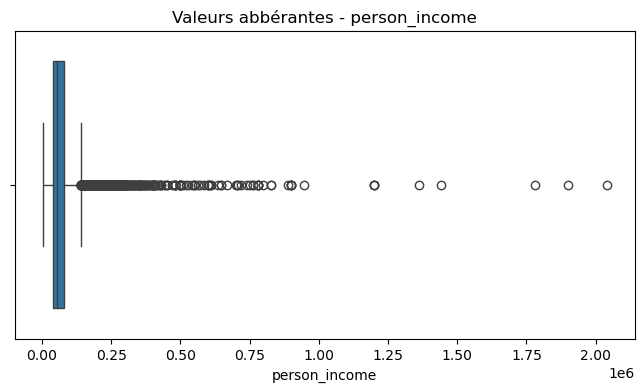

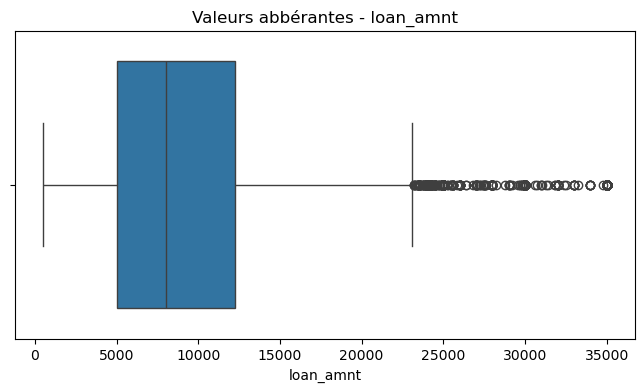

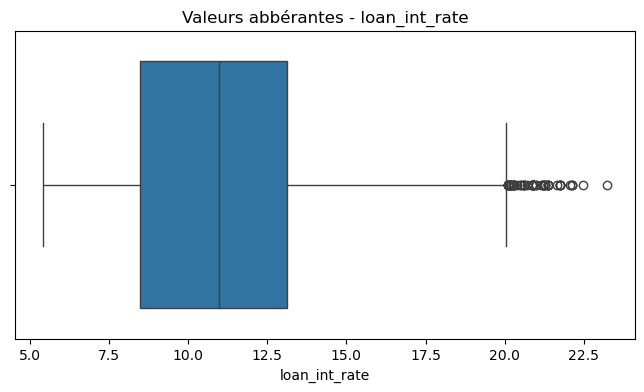

In [879]:
# Visualiser les valeurs abbérantes (outliers)
outlier_cols = ["person_income", "loan_amnt", "loan_int_rate"]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title (f"Valeurs abbérantes - {col}")
    plt.show()

- Appliquer le capping

In [880]:
# Limiter chaque variable au 99e percentile
df["person_income"] = df["person_income"].clip(upper=df["person_income"].quantile(0.99))
df["loan_amnt"] = df["loan_amnt"].clip(upper=df["loan_amnt"].quantile(0.99))
df["loan_int_rate"] = df["loan_int_rate"].clip(upper=df["loan_int_rate"].quantile(0.99))

# Créer un ratio dette / Revenu pour la suite
df["debt_to_income"] = df["loan_amnt"]/df["person_income"]
df["debt_to_income"] = df["debt_to_income"].clip(upper=df["debt_to_income"].quantile(0.99))

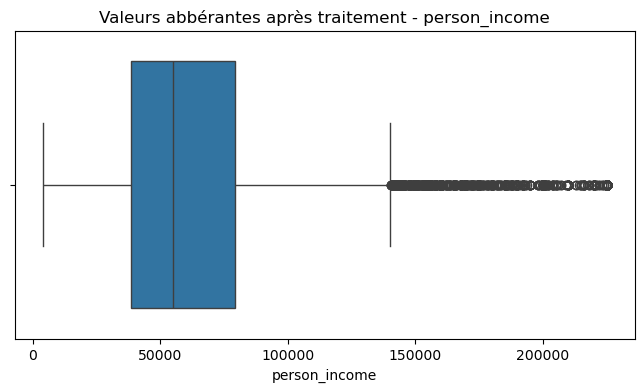

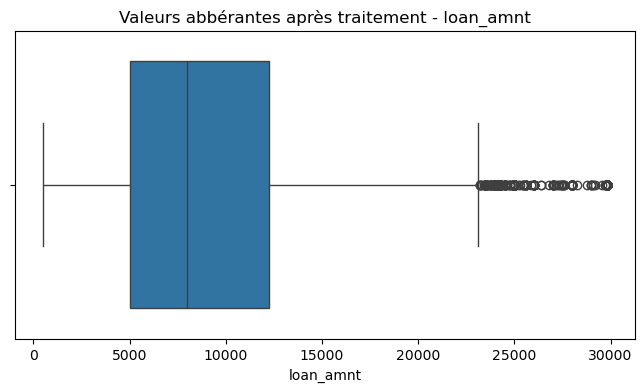

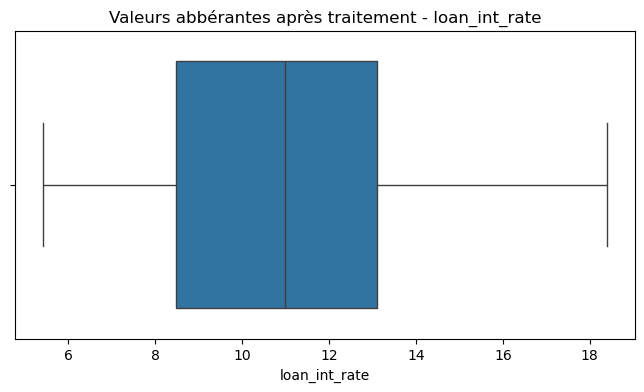

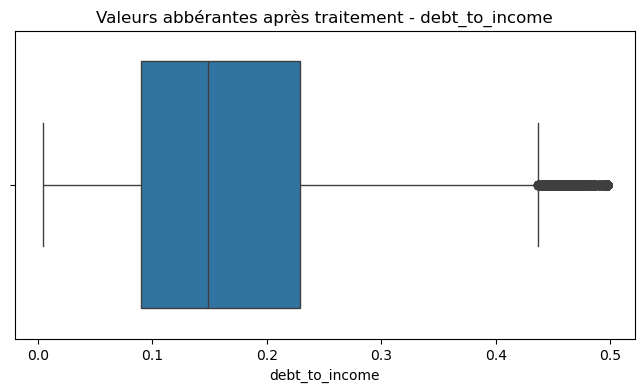

In [881]:
# Visualiser les outliers après traitement
outlier_cols = ["person_income", "loan_amnt", "loan_int_rate", "debt_to_income"]

for col in outlier_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title (f"Valeurs abbérantes après traitement - {col}")
    plt.show()

In [882]:
print("""Les valeurs aberrantes ont été traitées par capping au 99e percentile afin de conserver les observations tout en limitant l'effet 
 des extrêmes sur l'analyse.""")

Les valeurs aberrantes ont été traitées par capping au 99e percentile afin de conserver les observations tout en limitant l'effet 
 des extrêmes sur l'analyse.


7- Feature Engineering

- Créer le ratio de dette / revenu

In [883]:
print(""" Objectif : Mesurer du prêt par rapport au revenu
Pourquoi :
Un client avec un prêt très élevé par rapport au revenu est souvent plus risqué.""")

# Déjà fait plus haut 
#df["debt_to_income"] = df["loan_amnt"]/df["person_income"]

 Objectif : Mesurer du prêt par rapport au revenu
Pourquoi :
Un client avec un prêt très élevé par rapport au revenu est souvent plus risqué.


In [884]:
# vérification
df["person_income"].min()

4000

- Créer des groupes de revenu

In [885]:

print("""Objectif : 
Segmenter les clients selon leur niveau de revenu.
Pourquoi : Cela permet de voir rapidementsi les clients à faible revenu sont plus risqués. """)

df["income_group"] = pd.qcut(
    df["person_income"],
    4,
    labels= ["Low","Meduim", "High", "Very High"]
)

Objectif : 
Segmenter les clients selon leur niveau de revenu.
Pourquoi : Cela permet de voir rapidementsi les clients à faible revenu sont plus risqués. 


- Créer des groupes d'âges

In [886]:

print("""Objectif :
Etudier si le risque varie selon l'âge""")

df["age_group"]= pd.cut(
    df["person_age"], 
    bins=[18,25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "50+"]
)

Objectif :
Etudier si le risque varie selon l'âge


In [887]:
# Créer une variable plus lisible pour l'analyse
df["is_risky"] = df["loan_status"].apply(lambda x: 1 if x==1 else 0)

- réer une catégorie de montant de prêt 

In [888]:
# Créer éventuellement une catégorie de montant de prêt 
print(""" Objectif : 
Analyser les défauts selon le niveau de prêt """)

df["loan_amount_group"] = pd.qcut(
    df["loan_amnt"],
    4,
    labels=["Low", "Meduim", "High", "very High"]
)

 Objectif : 
Analyser les défauts selon le niveau de prêt 


8- Analyse exploratoire des données (EDA)

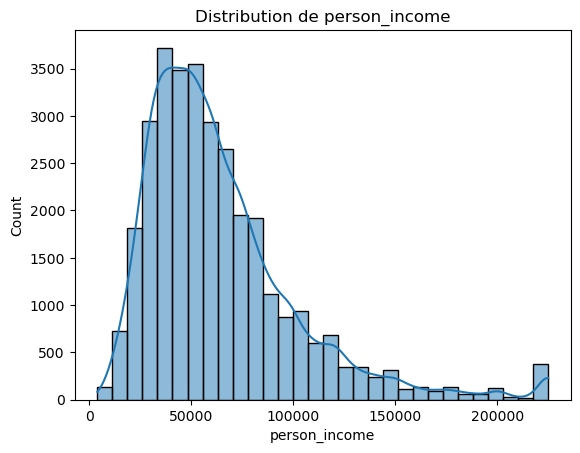

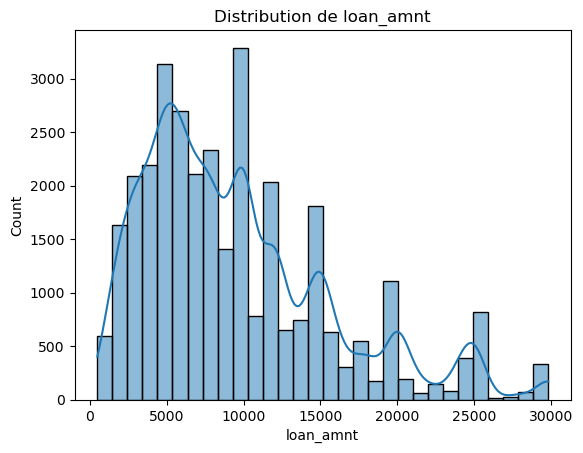

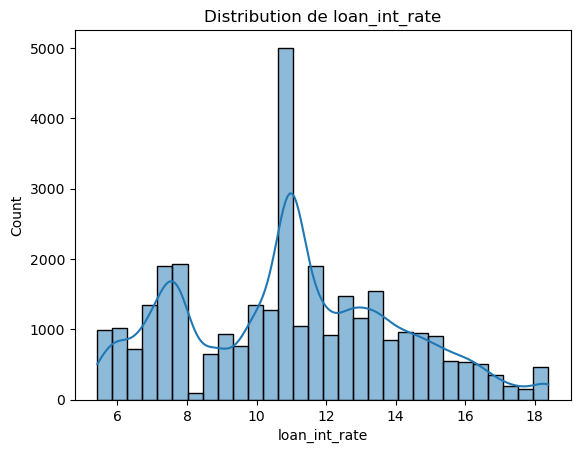

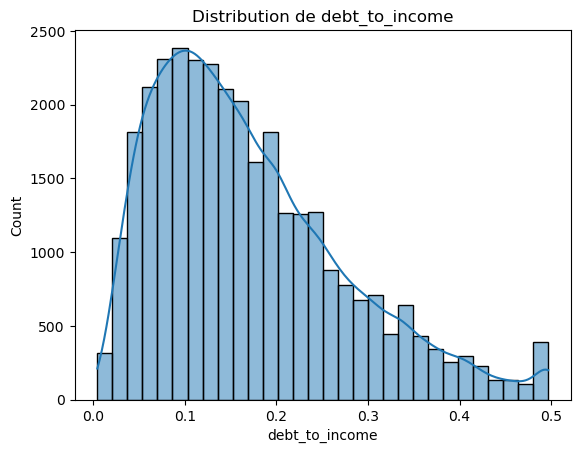

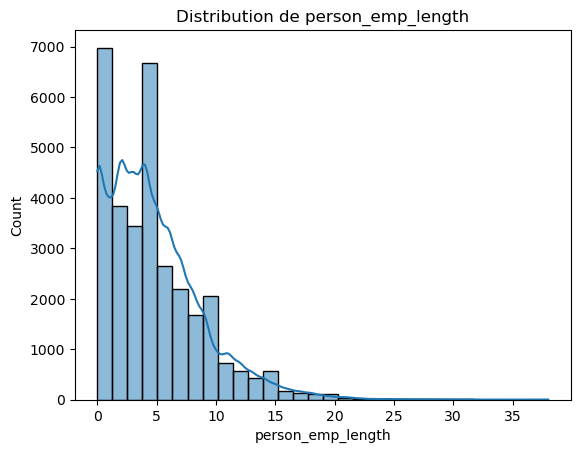

In [889]:
# Distribution des variables numériques
num_cols = ["person_income", "loan_amnt","loan_int_rate", "debt_to_income", "person_emp_length"]

for col in num_cols:
    plt.Figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")
    plt.show()

In [890]:
print("""
On observe pour la variable
    person_income   :  la distribution est très asymétrique à droite et beaucoup de clients sont concentrés sur les revenus à faible 
                       moyen.
    loan_amnt       :  la majorité des prêts sont plus concentés sur des niveaux modérés
                       Quelques prêts plus élevés

    loan_int_rate   :  Une concentration autour des taux moyens
                       Queue à droite pour les élevés
    debt_to_income  :  majorité des sous 0.3
                       une minorité beaucoup plus endettée
      
    person_emp_length: majorité des clients avec une ancienneté faible à modérée

""")


On observe pour la variable
    person_income   :  la distribution est très asymétrique à droite et beaucoup de clients sont concentrés sur les revenus à faible 
                       moyen.
    loan_amnt       :  la majorité des prêts sont plus concentés sur des niveaux modérés
                       Quelques prêts plus élevés

    loan_int_rate   :  Une concentration autour des taux moyens
                       Queue à droite pour les élevés
    debt_to_income  :  majorité des sous 0.3
                       une minorité beaucoup plus endettée
      
    person_emp_length: majorité des clients avec une ancienneté faible à modérée




9- Analyse du risque par segment 

In [891]:
# Taux de défaut par segment

df.groupby("income_group")["loan_status"].mean().sort_values()

df.groupby("age_group")["loan_status"].mean().sort_values()

df.groupby("loan_grade")["loan_status"].mean().sort_values()

df.groupby("person_home_ownership")["loan_status"].mean().sort_values()

# Cela permet d'identifier: 
# les groupes de revenus les plus à risque
# les tranches d'âge les plus fragiles
# les grades de prêt les plus risqués
# les profils clients les pus exposés

C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\2397591793.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_group")["loan_status"].mean().sort_values()
C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\2397591793.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["loan_status"].mean().sort_values()


person_home_ownership
OWN         0.074912
MORTGAGE    0.126235
OTHER       0.311321
RENT        0.316227
Name: loan_status, dtype: float64

- Taux de défaut par groupe de revenu

C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\302693187.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = df.groupby("income_group")["loan_status"].mean().reset_index()
C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\302693187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= default_by_income, x="income_group", y="loan_status", palette="viridis")


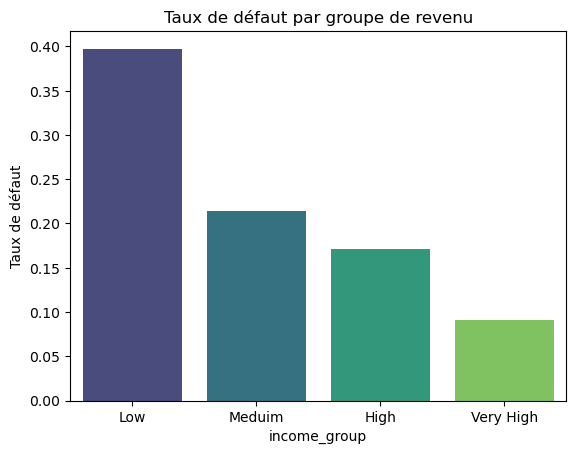

Les clients à faible revenu présentent un taux significativement plus élevé que les autres groupes.A mesure que le revenu
augmente, le risque de défaut diminue nettement Cela montre que le revenu est un facteur déterminant dans l'évaluation 
du risque de crédit.


In [892]:
# Visualiser le taux de défaut par groupe de revenu
default_by_income = df.groupby("income_group")["loan_status"].mean().reset_index()

plt.Figure(figsize=(8,4))
sns.barplot(data= default_by_income, x="income_group", y="loan_status", palette="viridis")
plt.title("Taux de défaut par groupe de revenu")
plt.ylabel("Taux de défaut")
plt.show();

print("""Les clients à faible revenu présentent un taux significativement plus élevé que les autres groupes.A mesure que le revenu
augmente, le risque de défaut diminue nettement Cela montre que le revenu est un facteur déterminant dans l'évaluation 
du risque de crédit.""")



- Taux de défaut par groupe d'âge 

C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\3887880931.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = df.groupby("age_group")["loan_status"].mean().reset_index()
C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\3887880931.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= default_by_age, x="age_group", y="loan_status", palette="viridis")


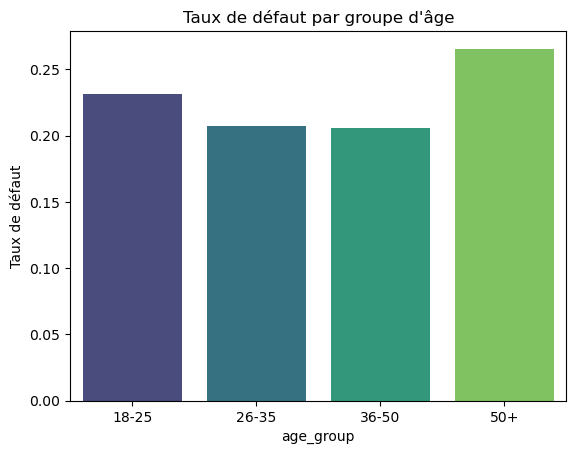

Les clients de plus de 50 ans présentent le taux de défaut le plus élevé. Les profils les plus jeunes sont également
relativement exposés, ce qui suggère que l'âge doit être pris en compte dans les politiques d'octroie de crédit.



In [893]:
default_by_age = df.groupby("age_group")["loan_status"].mean().reset_index()

plt.Figure(figsize=(8,4))
sns.barplot(data= default_by_age, x="age_group", y="loan_status", palette="viridis")
plt.title("Taux de défaut par groupe d'âge")
plt.ylabel("Taux de défaut")
plt.show()

print("""Les clients de plus de 50 ans présentent le taux de défaut le plus élevé. Les profils les plus jeunes sont également
relativement exposés, ce qui suggère que l'âge doit être pris en compte dans les politiques d'octroie de crédit.
""")

- Taux de défaut par statut résidentiel 

C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\900471056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= default_by_person_home_ownership, x="person_home_ownership", y="loan_status", palette="viridis")


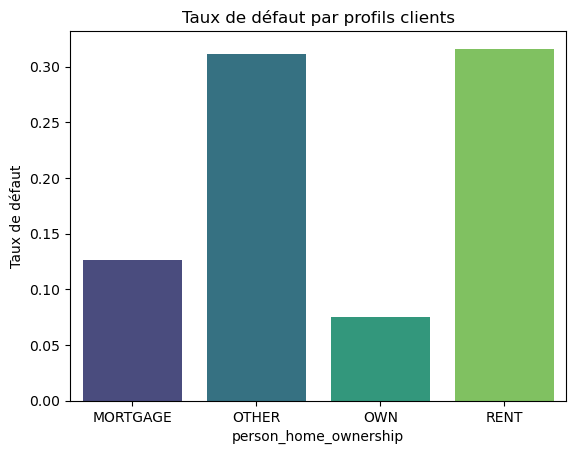

Les propriétaires présentent le taux de défaut le plus faible. A l'iverse, les locataires et certains profils non 
standard sont plus exposés au risque, ce qui suggère que la stabilité résidentielle joue un rôle important dans la solvabilité


In [894]:
default_by_person_home_ownership = df.groupby("person_home_ownership")["loan_status"].mean().reset_index()

plt.Figure(figsize=(8,4))
sns.barplot(data= default_by_person_home_ownership, x="person_home_ownership", y="loan_status", palette="viridis")
plt.title("Taux de défaut par profils clients")
plt.ylabel("Taux de défaut")
plt.show()

print("""Les propriétaires présentent le taux de défaut le plus faible. A l'iverse, les locataires et certains profils non 
standard sont plus exposés au risque, ce qui suggère que la stabilité résidentielle joue un rôle important dans la solvabilité""")

C:\Users\clifo\AppData\Local\Temp\ipykernel_6916\3000893781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= default_by_grade, x="loan_grade", y="loan_status", palette="viridis")


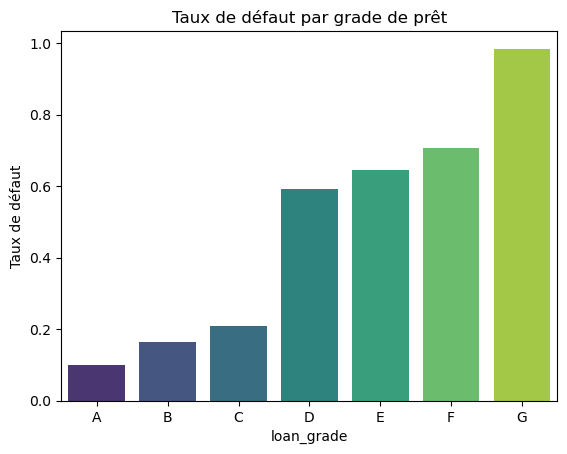

Les grades de prêt les plus élevés sont associés à un un taux de défaut plus élevé et inversement. Cela confirme la 
pertinence du grade comme indicateur de risque


In [895]:
default_by_grade = df.groupby("loan_grade")["loan_status"].mean().reset_index()

plt.Figure(figsize=(8,4))
sns.barplot(data= default_by_grade, x="loan_grade", y="loan_status", palette="viridis")
plt.title("Taux de défaut par grade de prêt")
plt.ylabel("Taux de défaut")
plt.show()

print("""Les grades de prêt les plus élevés sont associés à un un taux de défaut plus élevé et inversement. Cela confirme la 
pertinence du grade comme indicateur de risque""")

- Matrice de corrélation

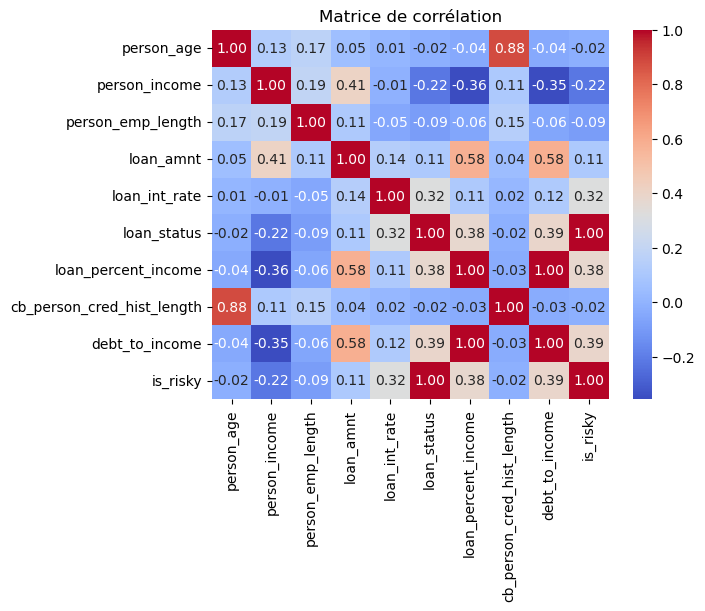

In [896]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

Conclusion:
L'analyse met en évidence plusieurs facteurs fortement liés au risque de défaut:
- un faible revenu
- un ratio  dette / revenu élevé
- un statut de locataire
- Certains segments d'âge
- des grades de prêt plus faible

Recommandations
- renforcer les contrôles sur les profils à faible revenu
- surveiller les clients avec un ratio dette / revenu élevé
- intégrer daavantage le statut résidentiel dans les politiques de scoring
- utiliser ces variables dans un futur modèle prédictif de défaut 

Exporter le dataset propre

In [897]:
df.to_csv("clean_credit_risk.csv", index= False)

10- Modèle de prédiction (Logistic Regression)


a- Objectif du modèle: 
- onstruire un modèle de machine learning capable de prédire si un client va faire défaut (loan_status) en se basant sur ces caractéristiques financières.
- Ce modèle permettra d'anticiper le risque et d'améliorer les décisions d'octroi de crédit.

b- Préparation des données 

In [898]:
from sklearn.model_selection import train_test_split

# Variable explicatives (features)

features = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "debt_to_income"
]
X =df[features] # Variables explicatives
y = df["loan_status"] # cible (défaut ou non)

# Division en données d'entrainement et de test
X_train, X_test, y_train, y_test =train_test_split(
    X, y, test_size=0.2, random_state=42             # On sépare les données pour éviter que le modèle apprenne par coeur
)

print("Train size : ", X_train.shape)
print("Test size :", X_test.shape)

Train size :  (25920, 4)
Test size : (6481, 4)


c- Entrainement du modèle 

In [899]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print(" Modèle bien entrainé avec succès")
print(" Nombre de variable : ", X_train.shape[1])

 Modèle bien entrainé avec succès
 Nombre de variable :  4


d- Prédiction et évaluation

In [900]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nRapport de classification : \n")
print(classification_report(y_test,y_pred))

Accuracy : 0.8299645116494369

Rapport de classification : 

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      5083
           1       0.69      0.38      0.49      1398

    accuracy                           0.83      6481
   macro avg       0.77      0.67      0.70      6481
weighted avg       0.81      0.83      0.81      6481



In [901]:
print("""
Après l'entraînement du modèle de régression logistique, une évaluation de performance a été réalisée à l'aide de l'accuracy_score
et rapport de classification.
Le modèle présente une accuracy globale satisfaisante d'environ 83%, ce qui pourrait penser à une bonne performance générale.
Cependant, une analyse plus détaillée montre une forte disparité entre les classes.
En particulier, le recall de la classe 1 (client en défaut) est faible (~38%), ce qui signifie que le modèle ne parvient à 
detecter qu'une faible proportion des clients à risque.
Ainsi, environ 62% des clients susceptibles de faire défaut ne sont pas identifiés par le modèle.
Ce problème est critique dans un contexte de risque de crédit, où l'objectif principal est détecter les clients présentant un
risque élevé de défaut.
Cette limitation s'explique notamment par le déséquilibre du dataset, où la classe des non-défauts est largement majoritaire, ce
qui pousse le modèle à privillégier cette classe.
Il est donc nécessaire d'améliorer le modèle afin de mieux détecter les clients à risque.
""")


Après l'entraînement du modèle de régression logistique, une évaluation de performance a été réalisée à l'aide de l'accuracy_score
et rapport de classification.
Le modèle présente une accuracy globale satisfaisante d'environ 83%, ce qui pourrait penser à une bonne performance générale.
Cependant, une analyse plus détaillée montre une forte disparité entre les classes.
En particulier, le recall de la classe 1 (client en défaut) est faible (~38%), ce qui signifie que le modèle ne parvient à 
detecter qu'une faible proportion des clients à risque.
Ainsi, environ 62% des clients susceptibles de faire défaut ne sont pas identifiés par le modèle.
Ce problème est critique dans un contexte de risque de crédit, où l'objectif principal est détecter les clients présentant un
risque élevé de défaut.
Cette limitation s'explique notamment par le déséquilibre du dataset, où la classe des non-défauts est largement majoritaire, ce
qui pousse le modèle à privillégier cette classe.
Il est donc nécessair

e- Amélioration du modèle de prédiction


- Réequilibrage avec class_weight

In [902]:
# On donne plus de poids à la classe minoritaire (défaut)
model= LogisticRegression(max_iter=1000, class_weight="balanced")

# Entrainement du modèle 
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

- Prédiction avec probabilités

In [903]:
# Probabilité que chaque client soit en défaut (classe 1)
y_proba= model.predict_proba(X_test)[:,1]

- Ajustement du seuil de décision

In [904]:
# On choisit un seuil plus bas pour détecter plus de défauts 
threshold = 0.3
# Conversion des probabilités en classe (0 ou 1)
y_pred =(y_proba > threshold).astype(int)

- évaluation du nouveau modèle

In [905]:
print ("Nouvelle accuracy :", accuracy_score(y_test, y_pred))
print("\nRapport de classification : \n")
print(classification_report(y_test,y_pred))

Nouvelle accuracy : 0.6023761765159698

Rapport de classification : 

              precision    recall  f1-score   support

           0       0.94      0.52      0.67      5083
           1       0.34      0.89      0.49      1398

    accuracy                           0.60      6481
   macro avg       0.64      0.71      0.58      6481
weighted avg       0.81      0.60      0.63      6481



f- matrice de confusion

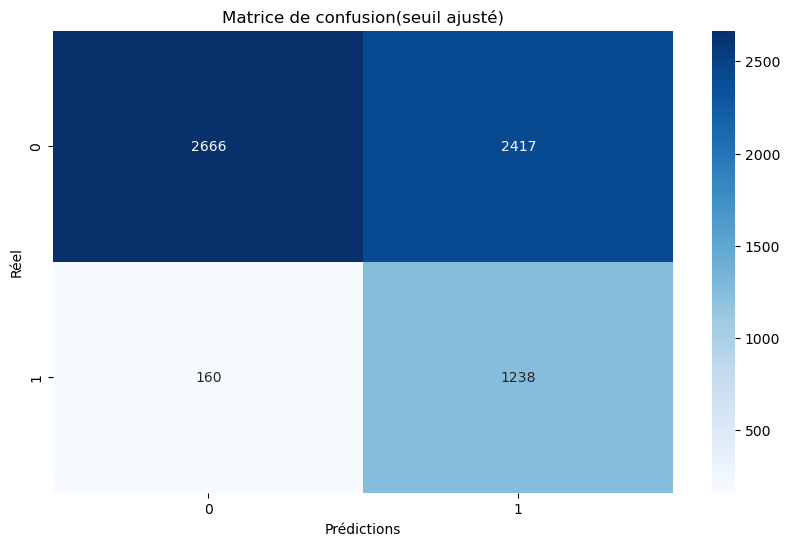

In [906]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix (y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt= "d", cmap="Blues")
plt.xlabel ("Prédictions")
plt.ylabel ("Réel")
plt.title("Matrice de confusion(seuil ajusté)")
plt.show()

- Interprétation simple:

1- Bon Clients (Classe 0): 
-2666 bien classés (correct)
-2417 faux positifs ( considérés à risque alors qu'ils ne le sont pas)

2- Clients à risque (classe 1)
- 1238 détectés  (excellent)
- 160 ratés (très faible)

L'analyse de la matrice de confusion met en évidence un changement significatif du comportement du modèle après ajustement du seuil.

Le nombre de défauts correctement détectés est élevé (1238), tandis que le nombre de défauts manqués est très faible (160), ce qui confirme une forte amélioration du recall de la classe à risque.

Cependant, cette amélioration s'accompagne d'une augmentation importante des faux positifs (2417), c'est-à-dire des clients considérés à risque alors qu'ils ne le sont pas en réellement.

Ce comportement traduit une stratégie plus prudente du modèle, qui privillégie la détention des défauts au détriment de la précision.

Dans un contexte de risque de crédit, ce comportement est pertinent, car le coût d'un défaut non détecté est géneralement plus élevé que celui d'un client refusé à tort.

g- Evaluation de la performance du modèle 
- Ajouter un ROC Curve

Il permet d'évaluer la performance globale du modèle indépendamment du seuil choisi, ce qui est essentiel dans les problèmes de classification déséquilibrée comme le risque du crédit. 

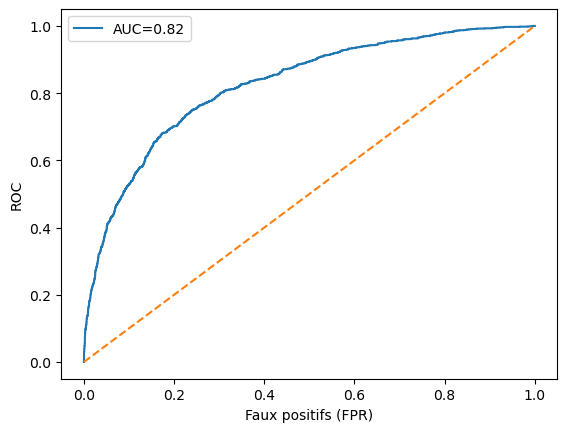

In [907]:
from sklearn.metrics import roc_curve,roc_auc_score
fpr, tpr, thresholds= roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.Figure(figsize=(10,6))
plt.plot(fpr, tpr, label=f"AUC={auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle= "--")
plt.xlabel("Faux positifs (FPR)")
plt.ylabel("ROC")
plt.legend()
plt.show()



In [908]:
print("""
La courbe ROC montre la capacité du modèle à distinguer les clients à risque des clients non risqués.

L'AUC obtenue est de 0.82, ce qui indique une bonne performance du modèle.

Cela signifie que dans 82% des cas, le modèle attribue une probabilté plus élevée à un client réellementen défaut 
qu'à un client non en défaut.
La courbe est nettement au-dessus de la diagonale, ce qui confirme que le modèle est bien meilleur qu'un modèle aléatoire.

Cependant, bien que la performance globale soit satisfaisante, l'analyse précédente a montré que le modèle initial avait
 du mal à détecter certains clients à risque, ce qui a nécessité un ajustement du seuil de décision.
      """)


La courbe ROC montre la capacité du modèle à distinguer les clients à risque des clients non risqués.

L'AUC obtenue est de 0.82, ce qui indique une bonne performance du modèle.

Cela signifie que dans 82% des cas, le modèle attribue une probabilté plus élevée à un client réellementen défaut 
qu'à un client non en défaut.
La courbe est nettement au-dessus de la diagonale, ce qui confirme que le modèle est bien meilleur qu'un modèle aléatoire.

Cependant, bien que la performance globale soit satisfaisante, l'analyse précédente a montré que le modèle initial avait
 du mal à détecter certains clients à risque, ce qui a nécessité un ajustement du seuil de décision.
      


Conclusion: 

L’évaluation du modèle montre une performance globale satisfaisante, avec une AUC de 0.82, indiquant une bonne capacité à distinguer les clients à risque des clients non risqués.

Cependant, l’analyse du rapport de classification révèle une faiblesse importante : le modèle initial détecte mal les clients en défaut (classe 1), avec un recall relativement faible.

Cela signifie qu’un grand nombre de clients à risque ne sont pas identifiés, ce qui représente un risque majeur dans un contexte de crédit.

Après ajustement du modèle (prise en compte du déséquilibre des classes et modification du seuil), le recall de la classe à risque s’améliore fortement, permettant de mieux détecter les défauts.

Cette amélioration se fait au détriment de la précision globale, mais elle est cohérente avec l’objectif métier, qui est de minimiser les pertes liées aux défauts de paiement.

La courbe ROC confirme que le modèle reste globalement performant, indépendamment du seuil choisi.

Ainsi, le modèle final privilégie la détection des clients à risque, ce qui en fait un outil pertinent pour l’aide à la décision en gestion du risque de crédit.

Bien que le modèle donne de bons résultats, plusieurs améliorations sont possibles :

- tester des modèles plus performants (Random Forest, XGBoost)
- optimiser les hyperparamètres
- intégrer davantage de variables explicatives
- améliorer le traitement du déséquilibre des classes
- calibrer les probabilités

Ces améliorations pourraient permettre d’augmenter la précision tout en maintenant un bon niveau de détection des défauts.